# From a point forecast to an interval: MC Dropout, deep ensembles, conformal

**Docker image**: `ml4t-gpu`

Every model in this chapter has returned one number per fund per day, and every
comparison has ranked those numbers. But a position size is not set by a forecast
alone: two funds with the same expected return and different confidence do not
deserve the same exposure. This notebook asks what a network can say about how sure
it is, and then whether that answer means anything.

It takes three steps, and the third is the one that matters.

**MC Dropout** (Gal and Ghahramani, 2016) keeps dropout switched on at inference and
runs the same input through the network many times, treating the spread of those
passes as uncertainty. It costs nothing extra to train.

**Deep ensembles** (Lakshminarayanan et al., 2017) train several networks that
differ only in initialisation and data order, and treat their disagreement as
uncertainty. It costs a full training run per member.

Both produce a number with the units of a return. Neither produces a number with a
coverage property, and the empirical coverage table below is where that becomes
visible. **Split-conformal calibration** is the step that converts a spread into an
interval with a coverage claim - under an exchangeability assumption this setup
does not fully satisfy, which is stated where it bites rather than in a footnote.

**Learning objectives**:
- Implement both methods and say precisely what quantity each one's spread is the
  spread *of*.
- Read an empirical coverage table and say what an under-covered interval means for
  a position-sizing rule built on it.
- Apply split-conformal calibration in both its plain and normalized forms, and say
  which of the two actually uses the model's uncertainty estimate.
- Name the exchangeability assumption conformal needs and the two places this
  notebook violates it.

**Book Reference**: Chapter 13, Section 13.8 (Quantifying prediction uncertainty)

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""Prediction Uncertainty - implement MC Dropout and Deep Ensembles for confidence estimation."""

import os

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from dl_sequences import create_sequences_multi_asset, load_dl_dataset
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from plotly.subplots import make_subplots
from scipy.stats import norm, spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.reproducibility import set_global_seeds
from utils.style import (  # COLORS activates the ml4t Plotly template on import
    COLORS,
    show_plotly_with_alt,
)

In [2]:
SEED = 42
MAX_SYMBOLS = 0
LOOKBACK = 60
LABEL_HORIZON = 21
HIDDEN_SIZE = 32
DROPOUT = 0.2
MC_SAMPLES = 50
N_ENSEMBLE = 5
EPOCHS = 30
BATCH_SIZE = 128
LR = 0.001

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cuda


## Data Loading

Both methods share identical data: ETF features and forward return labels from
the case study pipeline. Loading once eliminates the duplication that separate
notebooks would require.

In [4]:
mds = load_dl_dataset("etfs", max_symbols=MAX_SYMBOLS)

FEATURE_COLS = mds.feature_names[:8]
TARGET_COL = mds.label_col

df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")
print(f"Rows after dropna: {len(df):,}")
per_date = df.group_by(mds.date_col).len().sort(mds.date_col)
print(
    f"{df[mds.date_col].min()} to {df[mds.date_col].max()}, "
    f"{df[mds.entity_cols[0]].n_unique()} funds; funds per date "
    f"{per_date['len'].min()} to {per_date['len'].max()}, median {per_date['len'].median():.0f}"
)
print(
    f"Label {TARGET_COL}: mean {df[TARGET_COL].mean():+.5f}, "
    f"standard deviation {df[TARGET_COL].std():.5f}"
)

Loaded etfs: 402,526 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (8): ['ret_5d', 'ret_10d', 'ret_21d', 'ret_42d', 'ret_63d', 'ret_126d', 'ret_189d', 'ret_252d']
Target: fwd_ret_21d
Rows after dropna: 402,446
2007-01-04 to 2025-12-01, 99 funds; funds per date 47 to 96, median 90
Label fwd_ret_21d: mean +0.00692, standard deviation 0.06028


## Sequence Creation and Temporal Split

Two housekeeping steps before the split, both of which affect what the models see.

NaN and infinite feature values are replaced with zero. The features are already
standardized returns and a NaN here means a missing observation at a series
boundary, so zero is the standardized mean rather than an invented value.
Forward-filling within a symbol would be the other option and would not leak - it
only ever reads earlier observations - but it would present a stale value as a
current one, which for a trailing-return feature says the return was unchanged
rather than unknown. The count is printed so a large number cannot pass unnoticed.

The rows are then put in one canonical order, by date and then symbol. The sequence
builder pools assets in whatever order the frame yields them, and that order is not
fixed between runs - which changes which examples land in which mini-batch, and with
it every number below, seeds notwithstanding.

In [5]:
X, y, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)

n_nan = np.isnan(X).sum() + np.isinf(X).sum()

# One canonical row order, by date then symbol, so mini-batch composition does not
# depend on the order the sequence builder happened to pool assets in.
sequence_order = np.lexsort((symbols.astype(str), timestamps))
X = np.nan_to_num(X[sequence_order], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y = np.nan_to_num(y[sequence_order], nan=0.0).astype(np.float32)
timestamps = timestamps[sequence_order]
symbols = symbols[sequence_order]

print(f"Sequences: {X.shape[0]:,}, shape: {X.shape}")
print(f"NaN/inf values replaced with 0: {n_nan:,}")

Sequences: 396,506, shape: (396506, 60, 8)
NaN/inf values replaced with 0: 0


### Splitting by date, with a gap for the label horizon

The split is by date, at fixed fractions of the trading days, and an example belongs
to the partition the date it carries falls in. The label is a `LABEL_HORIZON`-session
forward return, so an example dated within that many sessions of a boundary has an
outcome resolved by days on the far side; those examples are dropped.

The gap matters more here than in the notebooks before it. The validation split is
not only where training stops early - it is also the calibration set for the
conformal intervals further down, and a conformal guarantee needs the calibration
residuals to be exchangeable with the test residuals. Validation examples whose
outcomes land inside the test period are not.

In [6]:
unique_dates = np.sort(np.unique(timestamps))
train_boundary_idx = int(len(unique_dates) * 0.6)
val_boundary_idx = int(len(unique_dates) * 0.8)
train_end_date = unique_dates[train_boundary_idx]
val_end_date = unique_dates[val_boundary_idx]
train_label_cutoff = unique_dates[train_boundary_idx - LABEL_HORIZON]
val_label_cutoff = unique_dates[val_boundary_idx - LABEL_HORIZON]

train_mask = timestamps < train_label_cutoff
val_mask = (timestamps >= train_end_date) & (timestamps < val_label_cutoff)
test_mask = timestamps >= val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(
    f"Purged {LABEL_HORIZON} target dates before each boundary: "
    f"validation starts {train_end_date}, test starts {val_end_date}"
)

Train: 216,040, Val: 87,638, Test: 88,817
Purged 21 target dates before each boundary: validation starts 2018-06-11, test starts 2022-03-04


**Cross-sectional IC helper**: every method below scores predictions with the same
daily Spearman correlation between forecast and forward return, averaged over the
test window. Defining it once keeps the comparison consistent.

A date's IC is undefined when a model predicts the same value for every fund on it:
the predicted ranks are all tied and there is nothing to correlate. The library
returns `NaN` for such a date, and polars treats `NaN` and null as different values,
so `drop_nulls` alone leaves it in place and one of them makes the whole mean `NaN`.
Both are filtered here, and the count of dates the mean was taken over is returned
alongside it.

In [7]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC over the dates where it is defined.

    Returns the mean and the defined/total date counts. Filters both null and NaN,
    since polars `drop_nulls` leaves NaN in place.
    """
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    defined = ic_per_date.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan())
    mean_ic = float(defined["ic"].mean()) if defined.height else float("nan")
    return {"ic": mean_ic, "n_defined": defined.height, "n_total": ic_per_date.height}

## Ridge Baseline

Both uncertainty methods need a point-prediction baseline for comparison.
We train Ridge once and reuse it throughout.

In [8]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_ridge = ridge.predict(X_test_scaled)

ridge_mse = np.mean((y_ridge - y_test) ** 2)
ridge_result = cross_sectional_ic_mean(y_test, y_ridge, test_dates, test_symbols)
ridge_ic = ridge_result["ic"]

print(f"Ridge baseline - MSE: {ridge_mse:.6f}, IC: {ridge_ic:+.4f}")
print(f"IC defined on {ridge_result['n_defined']} of {ridge_result['n_total']} test dates")

Ridge baseline - MSE: 0.003491, IC: +0.0151
IC defined on 940 of 940 test dates


---
## Part A: Monte Carlo Dropout

MC Dropout treats dropout as approximate Bayesian inference. By keeping dropout
**active at test time** and running multiple forward passes, we get a distribution
of predictions whose spread estimates model uncertainty.

The key insight from Gal and Ghahramani (2016): a neural network with dropout
applied before every weight layer is mathematically equivalent to an approximation
of a deep Gaussian process.

### LSTM with MC Dropout

This model has dropout in two places:
1. Between LSTM layers (via the `dropout` parameter)
2. Before the output head (explicit `nn.Dropout`)

At inference time, we call `model.train()` to keep both dropout layers active,
then run `MC_SAMPLES` forward passes to generate a prediction distribution.

In [9]:
class LSTMWithDropout(nn.Module):
    """LSTM with dropout that stays active at inference for MC estimation."""

    def __init__(self, input_size, hidden_size=32, n_layers=2, dropout=0.2):
        super().__init__()
        self.dropout_rate = dropout
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.head(lstm_out[:, -1, :]).squeeze(-1)

### Training

In [10]:
def train_lstm(
    model: nn.Module,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_v: np.ndarray,
    y_v: np.ndarray,
    epochs: int,
    lr: float,
    batch_size: int,
) -> float:
    """Train LSTM with mini-batch SGD and early stopping. Returns best val loss."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).to(DEVICE)
    X_v_t = torch.FloatTensor(X_v).to(DEVICE)
    y_v_t = torch.FloatTensor(y_v).to(DEVICE)

    best_val_loss = float("inf")
    best_state = None
    patience = 5
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_tr_t))

        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i : i + batch_size]
            optimizer.zero_grad()
            preds = model(X_tr_t[batch_idx])
            loss = criterion(preds, y_tr_t[batch_idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = torch.cat(
                [model(X_v_t[i : i + batch_size]) for i in range(0, len(X_v_t), batch_size)]
            )
            val_loss = criterion(val_preds, y_v_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch + 1}/{epochs}: val_loss={val_loss:.6f}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_loss

In [11]:
mc_model = LSTMWithDropout(
    input_size=len(FEATURE_COLS),
    hidden_size=HIDDEN_SIZE,
    n_layers=2,
    dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in mc_model.parameters())
print(f"MC Dropout LSTM parameters: {n_params:,}")

mc_val_loss = train_lstm(mc_model, X_train, y_train, X_val, y_val, EPOCHS, LR, BATCH_SIZE)
print(f"Best validation loss: {mc_val_loss:.6f}")

MC Dropout LSTM parameters: 14,369


  Epoch 1/30: val_loss=0.004477


  Early stopping at epoch 6
Best validation loss: 0.004477


### MC Inference

The critical step: switch to `model.train()` to keep dropout active, then
run `MC_SAMPLES` stochastic forward passes. Each pass samples a different
subset of neurons, approximating a draw from the posterior over model weights.

In [12]:
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

mc_model.train()  # Keep dropout active
mc_preds = np.zeros((MC_SAMPLES, len(X_test)))

with torch.no_grad():
    for i in range(MC_SAMPLES):
        batches = [
            mc_model(X_test_t[j : j + BATCH_SIZE]).cpu().numpy()
            for j in range(0, len(X_test_t), BATCH_SIZE)
        ]
        mc_preds[i] = np.concatenate(batches)

mc_mean = mc_preds.mean(axis=0)
mc_std = mc_preds.std(axis=0)

mc_mse = np.mean((mc_mean - y_test) ** 2)
mc_result = cross_sectional_ic_mean(y_test, mc_mean, test_dates, test_symbols)
mc_ic = mc_result["ic"]

print(f"MC Dropout ({MC_SAMPLES} samples) - MSE: {mc_mse:.6f}, IC: {mc_ic:+.4f}")
print(f"IC defined on {mc_result['n_defined']} of {mc_result['n_total']} test dates")
print(f"Mean uncertainty (std): {mc_std.mean():.6f}")
print(f"Ridge baseline IC for reference: {ridge_ic:+.4f}")

MC Dropout (50 samples) - MSE: 0.003302, IC: -0.0119
IC defined on 940 of 940 test dates
Mean uncertainty (std): 0.000647
Ridge baseline IC for reference: +0.0151


**Interpretation**: averaging `MC_SAMPLES` stochastic forward passes gives the MC
Dropout point estimate above. Two LSTM layers at a dropout rate of `DROPOUT` produce
highly correlated passes, so the spread of the resulting distribution is small in
absolute terms - compare the printed mean standard deviation against the label's own
standard deviation printed with the data. Which of the MC mean and the ridge
baseline scores higher moves between runs on this panel; the size of the
dropout spread relative to the return scale does not. The second observation is what
the calibration check below turns on.

### Calibration Helper

Both MC Dropout and Deep Ensembles need the same calibration diagnostic:
bin predictions by uncertainty quartile and check whether error tracks
uncertainty. We extract this into a reusable function.

In [13]:
def compute_calibration_table(std: np.ndarray, abs_error: np.ndarray) -> tuple[pl.DataFrame, float]:
    """Compute uncertainty calibration by quartile. Returns (table, Spearman correlation)."""
    quartile_bounds = np.percentile(std, [25, 50, 75])
    bins = np.digitize(std, quartile_bounds)
    labels = ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]

    rows = []
    for i in range(4):
        mask = bins == i
        if mask.sum() > 0:
            rows.append(
                {
                    "Quartile": labels[i],
                    "Mean Std": round(float(std[mask].mean()), 6),
                    "Mean |Error|": round(float(abs_error[mask].mean()), 6),
                    "Samples": int(mask.sum()),
                }
            )

    corr, _ = spearmanr(std, abs_error)
    table = pl.DataFrame(rows)
    return table, float(corr)

### Calibration Analysis

Well-calibrated uncertainty means: when the model says "I'm uncertain about
this prediction," the actual error should be proportionally larger. We bin
predictions by uncertainty quartile and check whether error tracks uncertainty.

In [14]:
mc_abs_error = np.abs(mc_mean - y_test)
mc_cal_table, unc_err_corr_mc = compute_calibration_table(mc_std, mc_abs_error)

print(f"MC Dropout - Uncertainty-Error correlation (Spearman): {unc_err_corr_mc:+.3f}")
mc_cal_table

MC Dropout - Uncertainty-Error correlation (Spearman): +0.073


Quartile,Mean Std,Mean |Error|,Samples
str,f64,f64,i64
"""Q1 (low)""",0.000258,0.038875,22204
"""Q2""",0.000311,0.035895,22204
"""Q3""",0.000403,0.040301,22204
"""Q4 (high)""",0.001615,0.047219,22205


**Interpretation**: the Spearman correlation printed above is the headline
calibration diagnostic - it asks whether the model's predicted std orders
absolute errors. The quartile table makes the same question concrete: does
mean |error| rise monotonically as you move from the low-std quartile (Q1) to
the high-std quartile (Q4)? With dropout active on only two LSTM layers, the
std spread is small in absolute terms; a near-zero correlation here means
that small spread carries little information about which predictions will be
wrong. The Q1→Q4 |error| gradient in the table is the visual version of the
same diagnostic.

### MC Dropout Visualization

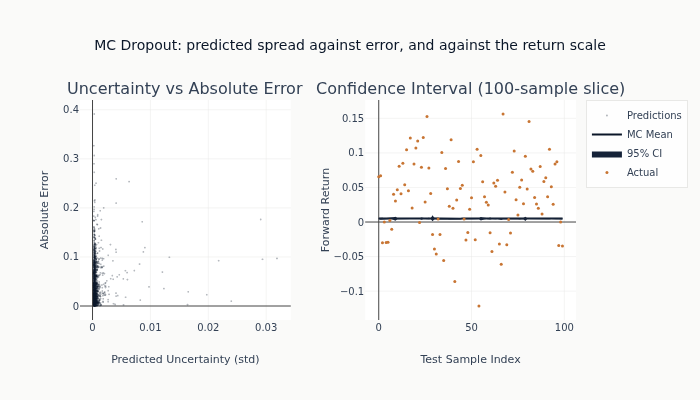

In [15]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Uncertainty vs Absolute Error",
        "Confidence Interval (100-sample slice)",
    ),
    horizontal_spacing=0.15,
)

# Scatter: uncertainty vs error (subsample for readability)
n_scatter = min(2000, len(mc_std))
idx = np.random.choice(len(mc_std), n_scatter, replace=False)
fig.add_trace(
    go.Scattergl(
        x=mc_std[idx],
        y=mc_abs_error[idx],
        mode="markers",
        marker=dict(size=2, opacity=0.3),
        name="Predictions",
    ),
    row=1,
    col=1,
)
fig.update_xaxes(title_text="Predicted Uncertainty (std)", row=1, col=1)
fig.update_yaxes(title_text="Absolute Error", row=1, col=1)

# Time slice: 100 test points with confidence band
slice_idx = slice(0, 100)
x_range = np.arange(100)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=mc_mean[slice_idx],
        mode="lines",
        name="MC Mean",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=np.concatenate([x_range, x_range[::-1]]),
        y=np.concatenate(
            [
                mc_mean[slice_idx] + 2 * mc_std[slice_idx],
                (mc_mean[slice_idx] - 2 * mc_std[slice_idx])[::-1],
            ]
        ),
        fill="toself",
        fillcolor=COLORS["blue_light"],
        line=dict(width=0),
        name="95% CI",
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_test[slice_idx],
        mode="markers",
        marker=dict(size=3, color=COLORS["copper"]),
        name="Actual",
    ),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Test Sample Index", row=1, col=2)
fig.update_yaxes(title_text="Forward Return", row=1, col=2)
fig.update_layout(
    height=400,
    title_text="MC Dropout: predicted spread against error, and against the return scale",
    showlegend=True,
)
show_plotly_with_alt(
    fig,
    "Two panels. The left scatters absolute prediction error against the predicted "
    "standard deviation, one point per test example. The right plots 100 consecutive "
    "test points: the MC Dropout mean as a line, a shaded 95 percent band around it, "
    "and the actual forward returns as markers. The band is far narrower than the "
    "scatter of actual returns around it.",
)

---
## Part B: Deep Ensembles

Deep Ensembles train $M$ independently initialized models and use their
disagreement as an uncertainty estimate. Unlike MC Dropout (which approximates
weight uncertainty within a single model), ensembles capture **functional
diversity** arising from different loss landscape minima.

### Ensemble Member Architecture

Each member is a simpler LSTM than the MC Dropout version: dropout only within
the LSTM layers (no extra dropout head). The diversity comes from random
initialization, not from stochastic regularization.

In [16]:
class LSTMRegressor(nn.Module):
    """Standard LSTM regressor for ensemble members."""

    def __init__(self, input_size, hidden_size=32, n_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.head(lstm_out[:, -1, :]).squeeze(-1)

### Training Ensemble Members

Each member receives a different random seed for weight initialization.
The training procedure is identical; only the starting point differs.

In [17]:
def train_member(
    seed: int,
    member_id: int,
) -> nn.Module:
    """Train a single ensemble member with the given seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = LSTMRegressor(
        input_size=len(FEATURE_COLS),
        hidden_size=HIDDEN_SIZE,
        n_layers=2,
        dropout=0.1,
    ).to(DEVICE)

    val_loss = train_lstm(model, X_train, y_train, X_val, y_val, EPOCHS, LR, BATCH_SIZE)
    print(f"  Member {member_id}: val_loss={val_loss:.6f}")
    return model

In [18]:
print(f"Training {N_ENSEMBLE} ensemble members...")
ensemble = []
for m in range(N_ENSEMBLE):
    seed = SEED + m * 1000
    member = train_member(seed, m)
    ensemble.append(member)

print(f"\nTrained {len(ensemble)} members successfully")

Training 5 ensemble members...


  Epoch 1/30: val_loss=0.004668


  Early stopping at epoch 6
  Member 0: val_loss=0.004668


  Epoch 1/30: val_loss=0.004665


  Early stopping at epoch 6
  Member 1: val_loss=0.004665


...

  Early stopping at epoch 6
  Member 2: val_loss=0.004859


  Epoch 1/30: val_loss=0.004813


  Early stopping at epoch 6
  Member 3: val_loss=0.004813


  Epoch 1/30: val_loss=0.004728


  Early stopping at epoch 7
  Member 4: val_loss=0.004717

Trained 5 members successfully


### Ensemble Predictions

Each member produces an independent point prediction. The ensemble mean is
the forecast; the ensemble standard deviation is the uncertainty estimate.

In [19]:
member_preds = np.zeros((N_ENSEMBLE, len(X_test)))

for i, model in enumerate(ensemble):
    model.eval()
    with torch.no_grad():
        batches = [
            model(X_test_t[j : j + BATCH_SIZE]).cpu().numpy()
            for j in range(0, len(X_test_t), BATCH_SIZE)
        ]
        member_preds[i] = np.concatenate(batches)

ens_mean = member_preds.mean(axis=0)
ens_std = member_preds.std(axis=0)

ens_mse = np.mean((ens_mean - y_test) ** 2)
ens_result = cross_sectional_ic_mean(y_test, ens_mean, test_dates, test_symbols)
ens_ic = ens_result["ic"]

print(f"Deep Ensemble ({N_ENSEMBLE} members) - MSE: {ens_mse:.6f}, IC: {ens_ic:+.4f}")
print(f"IC defined on {ens_result['n_defined']} of {ens_result['n_total']} test dates")
print(f"Mean uncertainty (std): {ens_std.mean():.6f}")

# Report individual member ICs for context
for i in range(N_ENSEMBLE):
    m_ic = cross_sectional_ic_mean(y_test, member_preds[i], test_dates, test_symbols)["ic"]
    print(f"  Member {i} IC: {m_ic:+.4f}")

Deep Ensemble (5 members) - MSE: 0.003355, IC: +0.0225
IC defined on 940 of 940 test dates
Mean uncertainty (std): 0.004310
  Member 0 IC: +0.0173
  Member 1 IC: +0.0315
  Member 2 IC: -0.0035
  Member 3 IC: +0.0266
  Member 4 IC: +0.0091


**Interpretation**: the member ICs printed above compare how well each member ranks
funds, and the ensemble mean's IC against their range says how much averaging
helped - it helps when members make errors that partly cancel.

Note that this says nothing about the uncertainty estimate. An IC is a rank
statistic, so two members can score identically while predicting quite different
magnitudes, and the ensemble's uncertainty is `ens_std`: the per-example standard
deviation across members, printed above as a mean and plotted as a histogram below.
Whether that quantity is informative is the calibration question, and it is answered
by the uncertainty-error diagnostics, not by the IC spread.

### Calibration Analysis

In [20]:
ens_abs_error = np.abs(ens_mean - y_test)
ens_cal_table, unc_err_corr_ens = compute_calibration_table(ens_std, ens_abs_error)

print(f"Deep Ensemble - Uncertainty-Error correlation (Spearman): {unc_err_corr_ens:+.3f}")
print(f"  vs MC Dropout above: {unc_err_corr_mc:+.3f}")
ens_cal_table

Deep Ensemble - Uncertainty-Error correlation (Spearman): +0.274
  vs MC Dropout above: +0.073


Quartile,Mean Std,Mean |Error|,Samples
str,f64,f64,i64
"""Q1 (low)""",0.002505,0.030953,22204
"""Q2""",0.003134,0.032433,22204
"""Q3""",0.003822,0.038707,22204
"""Q4 (high)""",0.007777,0.060948,22205


**Interpretation**: the two correlations are printed together above, so read them
side by side. The argument for expecting the ensemble's to be larger is that its
members are separate optimisations that can land in different places, where MC
Dropout samples subnetworks of one trained model - a narrower kind of variation. The
run either bears that out or does not.

What neither number can be is a calibration guarantee. A rank correlation between
predicted spread and absolute error says the ordering carries some information; it
says nothing about whether an interval of a given width contains the outcome as
often as it claims. That is what the coverage table measures, and what the
split-conformal section is for.

### Epistemic vs Aleatoric Decomposition

Deep ensembles naturally decompose total predictive uncertainty into two components:

$$\underbrace{\text{Var}[\hat{y}]}_{\text{total}} = \underbrace{\text{Var}_{\theta}[\mathbb{E}[y \mid x, \theta]]}_{\text{epistemic}} + \underbrace{\mathbb{E}_{\theta}[\text{Var}[y \mid x, \theta]]}_{\text{aleatoric}}$$

- **Epistemic uncertainty** (model uncertainty): variance of the ensemble means.
  Reducible with more data -- members disagree because they learned different
  functions from finite data.
- **Aleatoric uncertainty** (data uncertainty): average variance within each
  member. Irreducible -- inherent noise in the data generating process.

For regression with MSE loss (no per-member variance head), we approximate
epistemic uncertainty as ensemble disagreement and note that aleatoric
uncertainty would require heteroscedastic outputs.

In [21]:
# Epistemic: variance across member means (what we can estimate)
epistemic = ens_std**2

# Total variance of predictions
total_var = member_preds.var(axis=0)

print(f"Mean epistemic variance: {epistemic.mean():.8f}")
print(f"Mean total variance:     {total_var.mean():.8f}")

Mean epistemic variance: 0.00003291
Mean total variance:     0.00003291


**Note**: Without heteroscedastic output heads (where each member predicts both
$\mu$ and $\sigma^2$), total variance equals epistemic variance. A production
model would add per-member variance heads to separate aleatoric noise - the
irreducible uncertainty inherent in the data generating process. See section
13.8 for the full variance decomposition equation.

### Ensemble Member Agreement Visualization

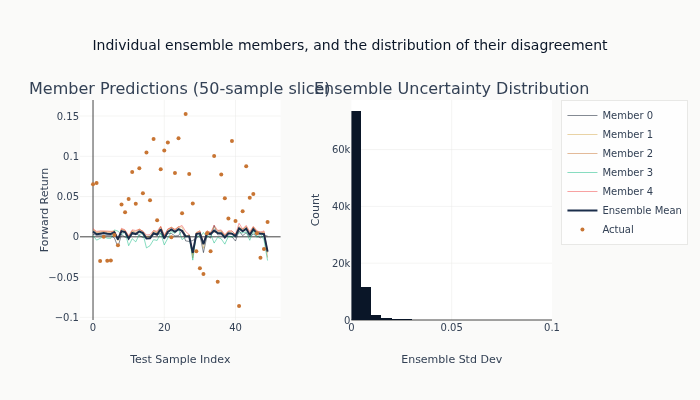

In [22]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Member Predictions (50-sample slice)",
        "Ensemble Uncertainty Distribution",
    ),
    horizontal_spacing=0.15,
)

# Member predictions slice
slice_range = np.arange(50)
for i in range(N_ENSEMBLE):
    fig.add_trace(
        go.Scatter(
            x=slice_range,
            y=member_preds[i, :50],
            mode="lines",
            name=f"Member {i}",
            opacity=0.5,
            line=dict(width=1),
        ),
        row=1,
        col=1,
    )

fig.add_trace(
    go.Scatter(
        x=slice_range,
        y=ens_mean[:50],
        mode="lines",
        name="Ensemble Mean",
        line=dict(color=COLORS["slate"], width=2),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=slice_range,
        y=y_test[:50],
        mode="markers",
        name="Actual",
        marker=dict(size=4, color=COLORS["copper"]),
    ),
    row=1,
    col=1,
)
fig.update_xaxes(title_text="Test Sample Index", row=1, col=1)
fig.update_yaxes(title_text="Forward Return", row=1, col=1)

# Uncertainty distribution
fig.add_trace(
    go.Histogram(
        x=ens_std, nbinsx=40, name="Ensemble Std", marker_color=COLORS["blue"], showlegend=False
    ),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Ensemble Std Dev", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.update_layout(
    height=400,
    title_text="Individual ensemble members, and the distribution of their disagreement",
)
show_plotly_with_alt(
    fig,
    "Two panels. The left plots each ensemble member's predictions over a slice of "
    "test points, with the ensemble mean drawn over them. The right is a histogram of "
    "the per-example standard deviation across members.",
)

---
## Part C: MC Dropout vs Deep Ensembles

We now compare both uncertainty methods head-to-head on the same test set,
alongside the Ridge baseline which provides no uncertainty estimate.

In [23]:
results = pl.DataFrame(
    {
        "Method": ["Ridge (baseline)", "MC Dropout", "Deep Ensemble"],
        "MSE": [ridge_mse, mc_mse, ens_mse],
        "Spearman IC": [ridge_ic, mc_ic, ens_ic],
        "Mean Uncertainty": [float("nan"), mc_std.mean(), ens_std.mean()],
        "Unc-Error Corr": [float("nan"), unc_err_corr_mc, unc_err_corr_ens],
        "Forward Passes": [1, MC_SAMPLES, N_ENSEMBLE],
    }
)
results

Method,MSE,Spearman IC,Mean Uncertainty,Unc-Error Corr,Forward Passes
str,f32,f64,f64,f64,i64
"""Ridge (baseline)""",0.003491,0.015128,NaN,NaN,1
"""MC Dropout""",0.003302,-0.011936,0.000647,0.072541,50
"""Deep Ensemble""",0.003355,0.022517,0.00431,0.273907,5


### Side-by-Side Calibration

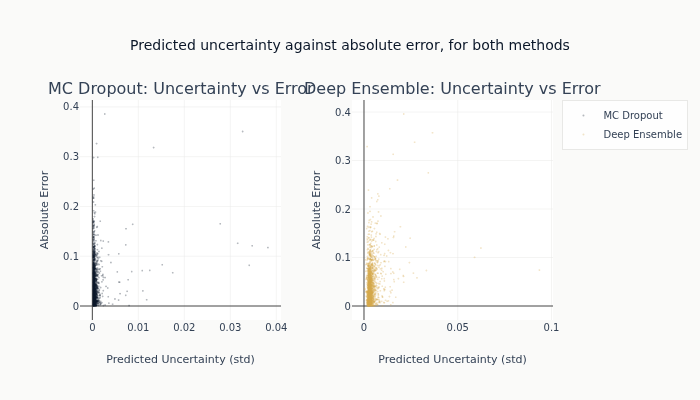

In [24]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "MC Dropout: Uncertainty vs Error",
        "Deep Ensemble: Uncertainty vs Error",
    ),
    horizontal_spacing=0.15,
)

n_scatter = min(2000, len(mc_std))
idx = np.random.choice(len(mc_std), n_scatter, replace=False)

fig.add_trace(
    go.Scattergl(
        x=mc_std[idx],
        y=mc_abs_error[idx],
        mode="markers",
        marker=dict(size=2, opacity=0.3, color=COLORS["blue"]),
        name="MC Dropout",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scattergl(
        x=ens_std[idx],
        y=ens_abs_error[idx],
        mode="markers",
        marker=dict(size=2, opacity=0.3, color=COLORS["amber"]),
        name="Deep Ensemble",
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="Predicted Uncertainty (std)", row=1, col=1)
fig.update_xaxes(title_text="Predicted Uncertainty (std)", row=1, col=2)
fig.update_yaxes(title_text="Absolute Error", row=1, col=1)
fig.update_yaxes(title_text="Absolute Error", row=1, col=2)
fig.update_layout(
    height=400,
    title_text="Predicted uncertainty against absolute error, for both methods",
)
show_plotly_with_alt(
    fig,
    "Two scatter panels on matching axes, absolute error against predicted standard "
    "deviation. The left panel is MC Dropout, the right the deep ensemble. The "
    "horizontal spread of each cloud shows how much uncertainty each method reports.",
)

### Coverage Probability

A complementary calibration diagnostic: what fraction of actual values fall
within the predicted confidence intervals? We compute empirical coverage at
the `nominal_levels` below for both methods, using the Gaussian assumption
($\mu \pm z_\alpha \cdot \sigma$).

In [25]:
nominal_levels = [0.50, 0.80, 0.95]
coverage_rows = []

for level in nominal_levels:
    z = norm.ppf(0.5 + level / 2)

    # MC Dropout coverage
    mc_lower = mc_mean - z * mc_std
    mc_upper = mc_mean + z * mc_std
    mc_cov = np.mean((y_test >= mc_lower) & (y_test <= mc_upper))

    # Deep Ensemble coverage
    ens_lower = ens_mean - z * ens_std
    ens_upper = ens_mean + z * ens_std
    ens_cov = np.mean((y_test >= ens_lower) & (y_test <= ens_upper))

    coverage_rows.append(
        {
            "Nominal": f"{level:.0%}",
            "MC Dropout": f"{mc_cov:.1%}",
            "Deep Ensemble": f"{ens_cov:.1%}",
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
coverage_df

Nominal,MC Dropout,Deep Ensemble
str,str,str
"""50%""","""0.8%""","""5.8%"""
"""80%""","""1.5%""","""10.8%"""
"""95%""","""2.4%""","""15.8%"""


**Interpretation**: both methods severely underestimate uncertainty under the
Gaussian assumption. The dropout-spread is tiny in absolute terms, so MC
Dropout's intervals are essentially zero-width and capture almost none of
the actual returns. The ensemble does better - its members genuinely
disagree - but the resulting intervals are still far too narrow at every
nominal level. The pattern is consistent across reruns: raw LSTM
uncertainty estimates are **not usable for risk management without
post-hoc calibration**. The next section uses split-conformal prediction to
convert these raw spreads into intervals with controlled empirical coverage.

### Split-Conformal Calibration

Split-conformal prediction (Vovk et al.) turns any point predictor into a
distribution-free interval estimator: under exchangeability of validation
and test residuals, the resulting test intervals have at least $1-\alpha$
marginal coverage in finite samples.

We implement two variants on the held-out validation set:

- **Plain conformal**: $q_\alpha = \mathrm{Quantile}_{1-\alpha}\big(|y_{\text{val}} - \hat\mu_{\text{val}}|\big)$,
  test interval $[\hat\mu_{\text{test}} - q_\alpha,\ \hat\mu_{\text{test}} + q_\alpha]$.
  Width is constant across test points.
- **Normalized (locally adaptive) conformal**: $q_\alpha = \mathrm{Quantile}_{1-\alpha}\big(|y_{\text{val}} - \hat\mu_{\text{val}}| / \hat\sigma_{\text{val}}\big)$,
  test interval $[\hat\mu_{\text{test}} - q_\alpha\,\hat\sigma_{\text{test}},\ \hat\mu_{\text{test}} + q_\alpha\,\hat\sigma_{\text{test}}]$.
  Width scales with the model's own uncertainty estimate, so well-calibrated
  $\hat\sigma$ yields tighter intervals where the model is confident.

We need validation predictions from MC Dropout and the ensemble. We re-run
inference on the val split.

**Two reasons the guarantee does not strictly hold here.** Both are about
exchangeability, which is the one assumption split-conformal makes.

First, the calibration set is the early-stopping set. The quantiles below come from
the same `X_val` split `train_lstm` stopped on, so the models were selected to make
these exact residuals small. That biases $|y_{\text{val}} - \hat\mu_{\text{val}}|$
downward and makes the intervals mildly optimistic. A production pipeline carves a
third, dedicated calibration split before training; this notebook reuses the
validation split to stay on one train/validation/test partition.

Second, the labels overlap. A `LABEL_HORIZON`-session forward return shares days
with its neighbours, so residuals within a split are strongly dependent rather than
exchangeable draws, and the effective sample size behind each quantile is far below
the row count. The split above purges the boundary, which stops calibration
residuals from resolving inside the test period; it does nothing about the
dependence within each split.

So read the coverage below as what these intervals achieved on this test set, not as
a finite-sample guarantee that they will.

In [26]:
X_val_t = torch.FloatTensor(X_val).to(DEVICE)

mc_model.train()  # keep dropout active for MC inference
mc_preds_val = np.zeros((MC_SAMPLES, len(X_val)))

with torch.no_grad():
    for i in range(MC_SAMPLES):
        batches = [
            mc_model(X_val_t[j : j + BATCH_SIZE]).cpu().numpy()
            for j in range(0, len(X_val_t), BATCH_SIZE)
        ]
        mc_preds_val[i] = np.concatenate(batches)

mc_mean_val = mc_preds_val.mean(axis=0)
mc_std_val = mc_preds_val.std(axis=0)
mc_resid_val = np.abs(mc_mean_val - y_val)

member_preds_val = np.zeros((N_ENSEMBLE, len(X_val)))
for i, model in enumerate(ensemble):
    model.eval()
    with torch.no_grad():
        batches = [
            model(X_val_t[j : j + BATCH_SIZE]).cpu().numpy()
            for j in range(0, len(X_val_t), BATCH_SIZE)
        ]
        member_preds_val[i] = np.concatenate(batches)

ens_mean_val = member_preds_val.mean(axis=0)
ens_std_val = member_preds_val.std(axis=0)
ens_resid_val = np.abs(ens_mean_val - y_val)

print(
    f"Val residuals - MC: mean |error| = {mc_resid_val.mean():.5f}, "
    f"Ensemble: mean |error| = {ens_resid_val.mean():.5f}"
)

Val residuals - MC: mean |error| = 0.04221, Ensemble: mean |error| = 0.04317


#### Calibration: plain and normalized conformal quantiles

`eps` guards the normalized variant against division by zero where the model
reports near-zero predicted std on the validation set.

In [27]:
def conformal_quantile(residuals: np.ndarray, alpha: float) -> float:
    """Finite-sample (1-α)·(n+1)/n quantile of |y − μ| - split-conformal width."""
    n = len(residuals)
    k = int(np.ceil((1 - alpha) * (n + 1)))
    k = min(k, n)
    return float(np.sort(residuals)[k - 1])


EPS = 1e-8
nominal_levels_conf = [0.50, 0.80, 0.95]
conf_rows = []

# Normalized conformal is invariant to rescaling sigma by a constant, so what decides
# whether it differs from plain conformal is how much sigma VARIES, not how large it
# is. Print that, and how close sigma gets to EPS, before reading the widths.
for _name, _sd in [("MC Dropout", mc_std_val), ("Deep Ensemble", ens_std_val)]:
    print(
        f"{_name} validation sigma: mean {_sd.mean():.3e}, "
        f"coefficient of variation {_sd.std() / _sd.mean():.3f}, "
        f"minimum {_sd.min():.3e} (EPS is {EPS:.0e})"
    )

for level in nominal_levels_conf:
    alpha = 1 - level

    # Plain conformal: constant-width intervals
    q_mc_plain = conformal_quantile(mc_resid_val, alpha)
    q_ens_plain = conformal_quantile(ens_resid_val, alpha)

    mc_cov_plain = np.mean((y_test >= mc_mean - q_mc_plain) & (y_test <= mc_mean + q_mc_plain))
    ens_cov_plain = np.mean((y_test >= ens_mean - q_ens_plain) & (y_test <= ens_mean + q_ens_plain))

    # Normalized conformal: width scales with predicted std
    q_mc_norm = conformal_quantile(mc_resid_val / (mc_std_val + EPS), alpha)
    q_ens_norm = conformal_quantile(ens_resid_val / (ens_std_val + EPS), alpha)

    mc_lo = mc_mean - q_mc_norm * mc_std
    mc_hi = mc_mean + q_mc_norm * mc_std
    ens_lo = ens_mean - q_ens_norm * ens_std
    ens_hi = ens_mean + q_ens_norm * ens_std

    mc_cov_norm = np.mean((y_test >= mc_lo) & (y_test <= mc_hi))
    ens_cov_norm = np.mean((y_test >= ens_lo) & (y_test <= ens_hi))

    mc_width_norm = float((mc_hi - mc_lo).mean())
    ens_width_norm = float((ens_hi - ens_lo).mean())

    conf_rows.append(
        {
            "Nominal": f"{level:.0%}",
            "MC plain cov": f"{mc_cov_plain:.1%}",
            "MC plain width": f"{2 * q_mc_plain:.5f}",
            "MC norm cov": f"{mc_cov_norm:.1%}",
            "MC norm width": f"{mc_width_norm:.5f}",
            "Ens plain cov": f"{ens_cov_plain:.1%}",
            "Ens plain width": f"{2 * q_ens_plain:.5f}",
            "Ens norm cov": f"{ens_cov_norm:.1%}",
            "Ens norm width": f"{ens_width_norm:.5f}",
        }
    )

conformal_df = pl.DataFrame(conf_rows)
conformal_df

MC Dropout validation sigma: mean 7.348e-04, coefficient of variation 2.934, minimum 1.417e-04 (EPS is 1e-08)
Deep Ensemble validation sigma: mean 4.588e-03, coefficient of variation 0.965, minimum 2.159e-04 (EPS is 1e-08)


Nominal,MC plain cov,MC plain width,MC norm cov,MC norm width,Ens plain cov,Ens plain width,Ens norm cov,Ens norm width
str,str,str,str,str,str,str,str,str
"""50%""","""46.9%""","""0.05387""","""45.5%""","""0.07782""","""47.2%""","""0.05443""","""45.4%""","""0.05861"""
"""80%""","""79.5%""","""0.12655""","""78.4%""","""0.20605""","""79.9%""","""0.12893""","""78.5%""","""0.13549"""
"""95%""","""96.8%""","""0.26576""","""95.4%""","""0.43625""","""97.1%""","""0.27759""","""95.8%""","""0.28106"""


**Reading the table.** Compare the empirical coverage column against the nominal
level, and the two variants against each other at the same level.

The plain variant uses no $\hat\sigma$ at all: it takes a quantile of the held-out
absolute residuals and gives every test point that same half-width. So its coverage
is a statement about the calibration procedure, not about either uncertainty method.
The normalized variant divides each residual by the model's own $\hat\sigma$ before
taking the quantile, then multiplies back at test time - which is the only place in
this notebook where MC Dropout's or the ensemble's spread does any work.

A small $\hat\sigma$ is not itself a problem. Multiplying every $\hat\sigma$ by a
constant divides the quantile by that constant and multiplies the width back by it,
leaving the intervals unchanged - so the normalized variant is scale-invariant, and a
method reporting standard deviations of $10^{-5}$ is on the same footing as one
reporting $10^{-1}$. A $\hat\sigma$ that is exactly constant reproduces the plain
widths.

What decides the outcome is how much $\hat\sigma$ varies, and whether it varies
where the errors are. The coefficients of variation printed above are the first thing
to read. A $\hat\sigma$ that barely varies leaves the normalized variant doing what
plain conformal already does. A $\hat\sigma$ that varies without tracking error
still redistributes width - some test points get a narrower interval and some a wider
one - but it allocates that width by something unrelated to where the model is
actually wrong. Marginal coverage still holds, because the quantile is chosen to make
it hold; what degrades is coverage *per point*, which is the property a position
sizer built on these intervals would rely on. The widths and coverage in the table
are the evidence, not the size of $\hat\sigma$.

The scale invariance does break at the bottom, where $\hat\sigma$ approaches `EPS`.
The printed minima say whether that is in play.

The marginal coverage guarantee is distribution-free (Vovk et al. 2005), but it is
not assumption-free: it needs calibration and test residuals to be exchangeable,
which the two paragraphs above the calibration set out is not the case here.

### Uncertainty-Based Prediction Filtering

The practical payoff: does removing the most uncertain predictions improve
forecast quality? We exclude the highest-uncertainty quartile and compare IC
on the filtered subset against the full test set.

In [28]:
q75_mc = np.percentile(mc_std, 75)
q75_ens = np.percentile(ens_std, 75)

mc_keep = mc_std <= q75_mc
ens_keep = ens_std <= q75_ens

mc_full_result = cross_sectional_ic_mean(y_test, mc_mean, test_dates, test_symbols)
mc_filtered_result = cross_sectional_ic_mean(
    y_test[mc_keep], mc_mean[mc_keep], test_dates[mc_keep], test_symbols[mc_keep]
)
ens_full_result = cross_sectional_ic_mean(y_test, ens_mean, test_dates, test_symbols)
ens_filtered_result = cross_sectional_ic_mean(
    y_test[ens_keep], ens_mean[ens_keep], test_dates[ens_keep], test_symbols[ens_keep]
)

mc_ic_full, ens_ic_full = mc_full_result["ic"], ens_full_result["ic"]
mc_ic_filtered, ens_ic_filtered = mc_filtered_result["ic"], ens_filtered_result["ic"]
print(
    f"Dates the IC is defined on - MC {mc_full_result['n_defined']} full, "
    f"{mc_filtered_result['n_defined']} filtered; ensemble "
    f"{ens_full_result['n_defined']} full, {ens_filtered_result['n_defined']} filtered"
)

filter_rows = [
    {
        "Method": "MC Dropout",
        "IC (full)": f"{mc_ic_full:+.4f}",
        "IC (filtered Q1-Q3)": f"{mc_ic_filtered:+.4f}",
        "Samples removed": f"{(~mc_keep).sum():,}",
    },
    {
        "Method": "Deep Ensemble",
        "IC (full)": f"{ens_ic_full:+.4f}",
        "IC (filtered Q1-Q3)": f"{ens_ic_filtered:+.4f}",
        "Samples removed": f"{(~ens_keep).sum():,}",
    },
]

filter_df = pl.DataFrame(filter_rows)
filter_df

Dates the IC is defined on - MC 940 full, 940 filtered; ensemble 940 full, 935 filtered


Method,IC (full),IC (filtered Q1-Q3),Samples removed
str,str,str,str
"""MC Dropout""","""-0.0119""","""-0.0156""","""22,204"""
"""Deep Ensemble""","""+0.0225""","""+0.0447""","""22,204"""


**Interpretation**: the filtering table above answers a concrete question -
does excluding the most uncertain quartile improve IC? The expected direction
is yes for a well-calibrated method; the realised direction and magnitude
vary across reruns at this signal-to-noise ratio. The result that does
survive reruns is the calibration story from the uncertainty-error
correlation: the ensemble's disagreement tracks error more reliably than MC
Dropout's dropout-spread. The ensemble result supports position sizing
(Chapter 19): scale exposure inversely with ensemble uncertainty, even when
simple quartile filtering moves IC only a few thousandths.

### Where this connects

- **The general framework** is Section 11.5, "Quantifying predictive uncertainty",
  which covers calibration for classification - Platt scaling and isotonic
  regression - alongside the distribution-free interval construction used here.
- **Conformal allocation** is where these widths are actually spent. The
  `conformal_weighted` allocator in `case_studies/utils/allocation.py` consumes
  per-prediction widths built by `case_studies/utils/conformal.py`: the same
  construction as this section, stratified by symbol and fold over the registry's
  stored predictions rather than a single split.
- **Position sizing** from an uncertainty estimate is Chapter 17's territory, where
  allocators turn scores into weights, and Section 19.7, "Adaptive risk controls
  without leakage", for the timing question - an exposure rule that reads a
  quantity computed with future information is the same defect as a leaky feature.
- **Wrapping other architectures**: nothing here is specific to the LSTM.
  `01_core_architectures` and `04_transformers` take dropout and can be ensembled
  the same way. The foundation models in `09_foundation_models` are the harder
  case: their calibration depends on a pretraining distribution you cannot inspect.
- **Saving ensemble members**: `torch.save(model.state_dict(), path)` per member,
  reloaded into a matching architecture.

## Key Takeaways

1. **MC Dropout is cheap**: Run $T$ forward passes through a single trained model.
   No extra training cost - just keep dropout active via `model.train()` at inference.

2. **A deep ensemble costs $M$ trainings and buys functional diversity.** Members
   differ only in their initialisation and their data order, so their disagreement
   is a measure of how underdetermined the fit is. Whether that disagreement tracks
   error better than dropout spread is measured above, in the two scatter panels and
   the correlations printed beside them - read those rather than assuming an
   ordering.

3. **A spread is not an interval until something calibrates it.** Both methods
   produce a number with the units of the label, and neither produces a number with
   a coverage property. The empirical coverage table is where that gap is visible,
   and it is the reason the conformal section exists.

4. **Split-conformal converts a spread into a coverage claim - under one
   assumption.** Calibrating against held-out residuals needs those residuals to be
   exchangeable with the test ones. Here they are not, twice over: the calibration
   split is also the early-stopping split, and overlapping forward-return labels
   make residuals dependent within each split. The measured coverage is what these
   intervals achieved, not what they are guaranteed to achieve.

5. **The normalized variant is where the uncertainty estimate earns its keep.**
   Plain conformal gives every test point the same width and needs no $\hat\sigma$
   at all. Only the normalized variant uses the model's own spread, so comparing the
   two is what says whether MC Dropout or the ensemble contributed anything beyond a
   constant.

6. **Separating aleatoric from epistemic needs a different head.** Splitting data
   noise from model uncertainty requires an output that predicts $\mu$ and
   $\sigma^2$ together; neither method here provides one, so the decomposition
   below is bounded by what a point-prediction head can express.

**Known limitations.** One chronological split of one ETF panel, one label horizon,
one seed, one architecture, and a calibration set that doubles as the
early-stopping set. Every coverage number is a single test-set measurement, not a
guarantee.

**Next**: `11_library_landscape` puts these architectures behind the interfaces the
forecasting libraries expose, so a model swap stops being a rewrite.